In [1]:
import sys
from pathlib import Path

ML_ROOT = Path.cwd().parent
if str(ML_ROOT) not in sys.path:
    sys.path.append(str(ML_ROOT))

print(ML_ROOT)
from src.preprocessing.normalizer import (
    normalize_heartbeat,
    normalize_dataset
)

c:\Abhiram\Projects\ecg-cardiac-abnormality-detection\ml


In [2]:
from src.datasets.dataset_builder import build_dataset
from src.config.constants import MITBIH_RECORDS

X, y, patient_ids = build_dataset(MITBIH_RECORDS)

Processing record 100...
Processing record 101...
Processing record 102...
Processing record 103...
Processing record 104...
Processing record 105...
Processing record 106...
Processing record 107...
Processing record 108...
Processing record 109...
Processing record 111...
Processing record 112...
Processing record 113...
Processing record 114...
Processing record 115...
Processing record 116...
Processing record 117...
Processing record 118...
Processing record 119...
Processing record 121...
Processing record 122...
Processing record 123...
Processing record 124...
Processing record 200...
Processing record 201...
Processing record 202...
Processing record 203...
Processing record 205...
Processing record 207...
Processing record 208...
Processing record 209...
Processing record 210...
Processing record 212...
Processing record 213...
Processing record 214...
Processing record 215...
Processing record 217...
Processing record 219...
Processing record 220...
Processing record 221...


In [3]:
heartbeat = X[0]

normalized_heartbeat = normalize_heartbeat(heartbeat)

print("Original mean:", heartbeat.mean())
print("Original std:", heartbeat.std())

print()

print("Normalized mean:", normalized_heartbeat.mean())
print("Normalized std:", normalized_heartbeat.std())

Original mean: -0.31664
Original std: 0.2015954126462207

Normalized mean: -1.1368683772161603e-16
Normalized std: 0.9999999503956991


In [4]:
X_normalized = normalize_dataset(X)

print(X_normalized.shape)

(100022, 250)


In [5]:
print(X_normalized[0].mean())
print(X_normalized[0].std())

-1.1368683772161603e-16
0.9999999503956991


In [6]:
means = X_normalized.mean(axis=1)
stds = X_normalized.std(axis=1)

print("Mean range:")
print(means.min(), means.max())

print()

print("Std range:")
print(stds.min(), stds.max())

Mean range:
-9.677592061052565e-15 2.5011104298755525e-15

Std range:
0.9999995901068167 0.9999999957421349


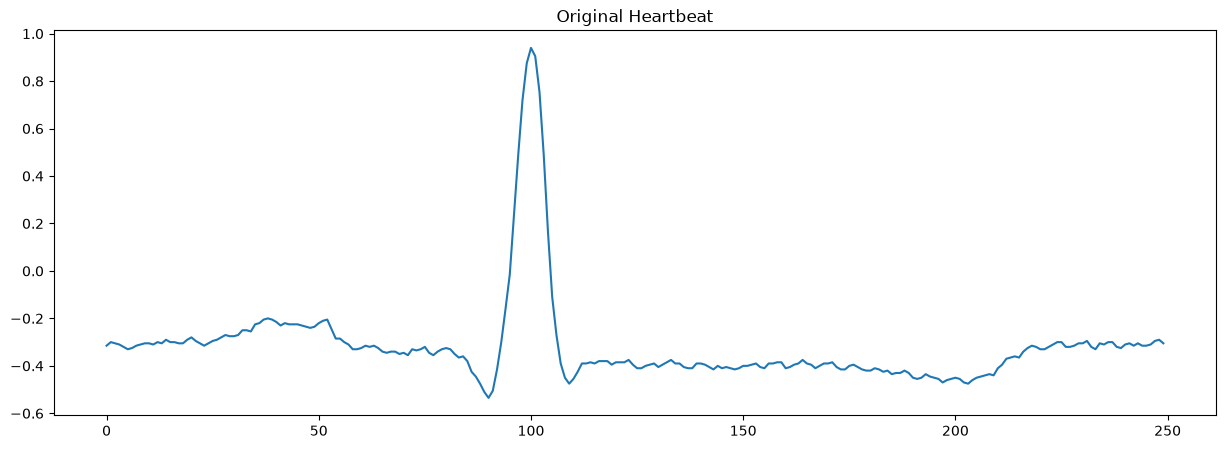

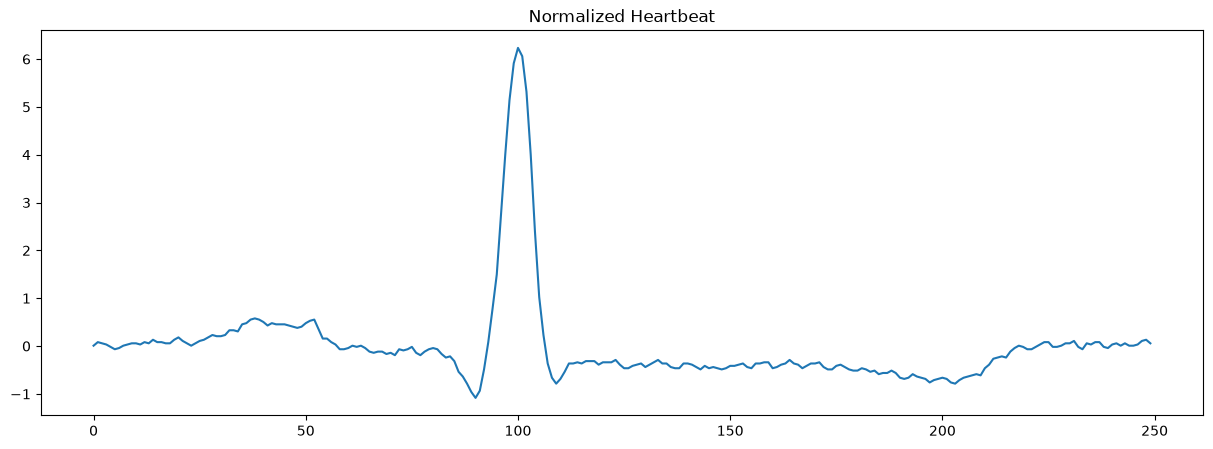

In [7]:
import matplotlib.pyplot as plt

idx = 0

plt.figure(figsize=(15,5))
plt.plot(X[idx])
plt.title("Original Heartbeat")
plt.show()

plt.figure(figsize=(15,5))
plt.plot(X_normalized[idx])
plt.title("Normalized Heartbeat")
plt.show()

In [8]:
from src.preprocessing.encoder import (
    encode_labels,
    decode_labels
)

y_encoded = encode_labels(y)

print(y[:10])
print(y_encoded[:10])

decoded = decode_labels(y_encoded[:10])

print(decoded)

['N' 'N' 'N' 'N' 'N' 'N' 'A' 'N' 'N' 'N']
[0 0 0 0 0 0 1 0 0 0]
['N' 'N' 'N' 'N' 'N' 'N' 'A' 'N' 'N' 'N']


In [9]:
import numpy as np
if np.array_equal(
    decode_labels(encode_labels(y)),
    y
):
    print("Encoder validation passed.")

Encoder validation passed.
